In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('../data/raw/housing.csv')

In [12]:
print(df.shape)
print("\nFirst five rows\n")
print(df.head())

(20640, 10)

First five rows

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [14]:
print("\nMissing values by column:\n")
print(df.isnull().sum())


Missing values by column:

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [15]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


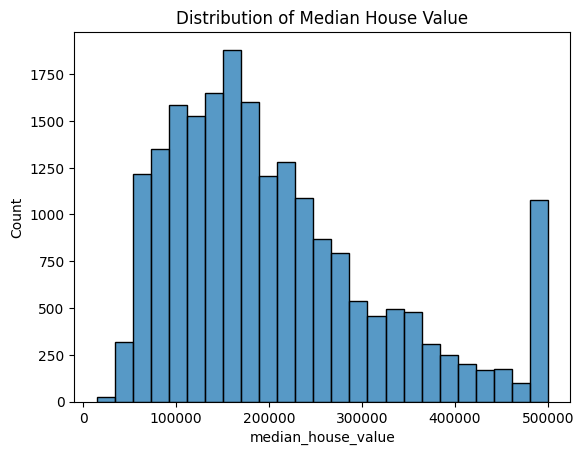

In [19]:
target = 'median_house_value'
sns.histplot(df[target], bins=25)
plt.title("Distribution of Median House Value")
plt.show()

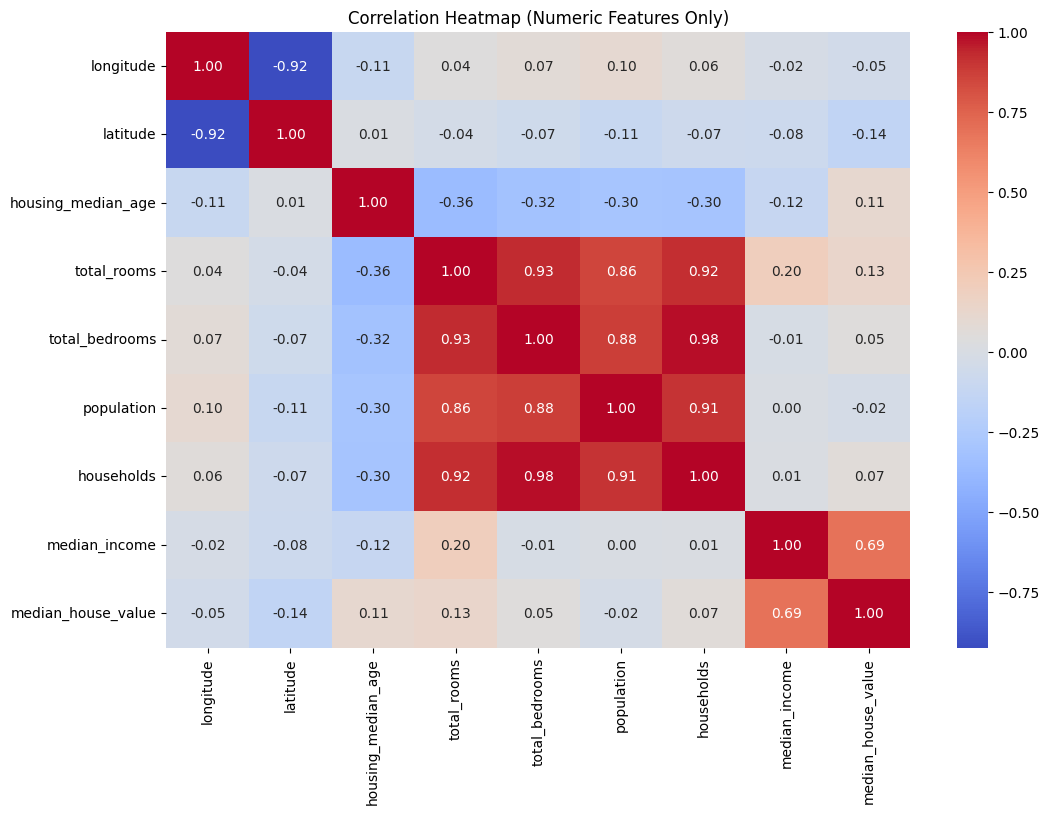

In [20]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

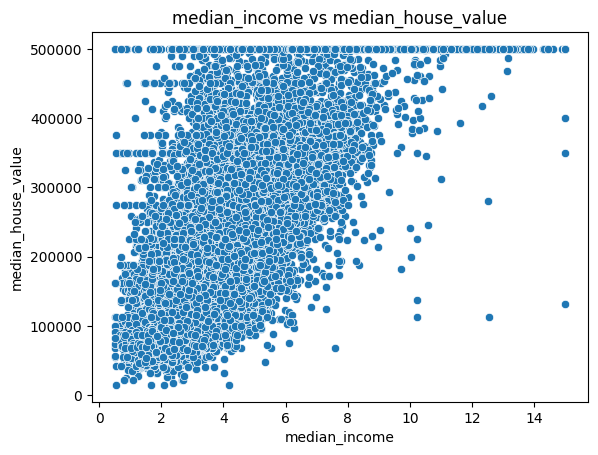

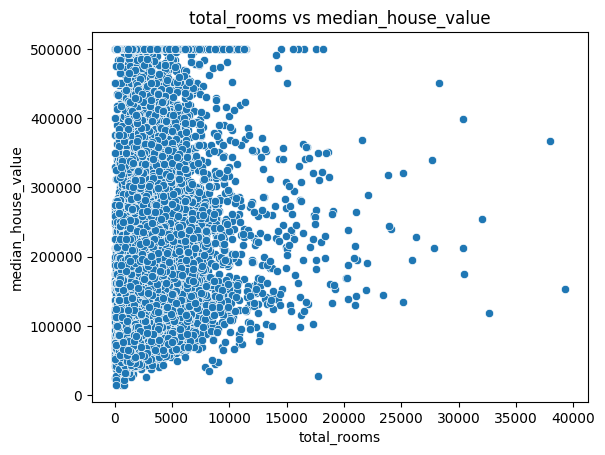

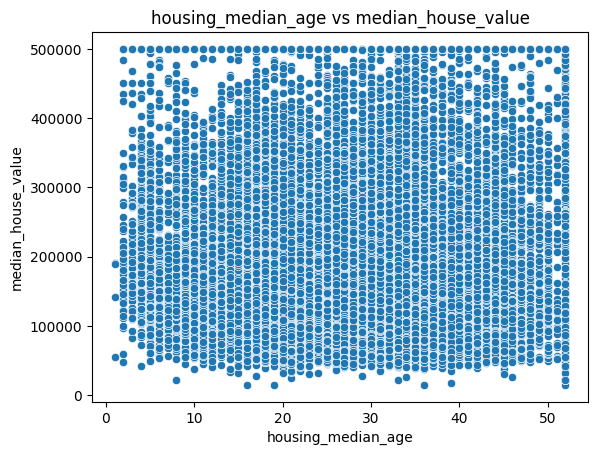

In [21]:
features = ['median_income', 'total_rooms', 'housing_median_age']

for col in features:
    sns.scatterplot(x=df[col], y=df[target])
    plt.title(f"{col} vs {target}")
    plt.show()

<Axes: xlabel='latitude', ylabel='longitude'>

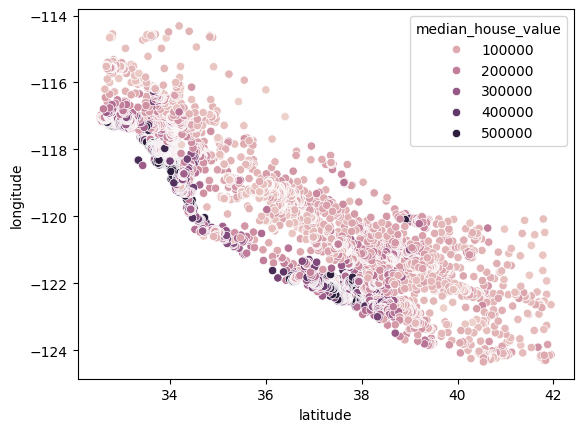

In [27]:
temp = pd.to_numeric(df['median_house_value'], errors='coerce')
sns.scatterplot(x=df['latitude'], y=df['longitude'], hue=temp)

In [31]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

median_house_value          1.000000
rooms_per_household         0.151948
population_per_household   -0.023737
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64


<Axes: >

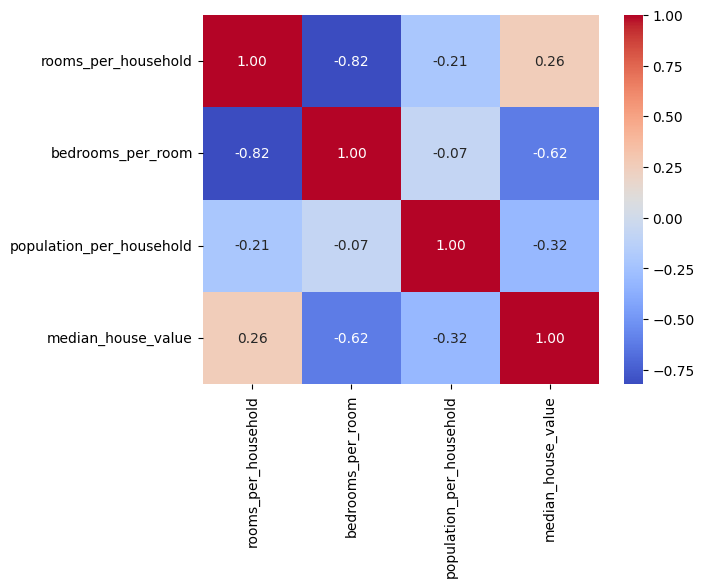

In [33]:
corr_matrix = df[[
    'rooms_per_household', 
    'bedrooms_per_room', 
    'population_per_household', 
    'median_house_value'
]].corr()

print(corr_matrix['median_house_value'].sort_values(ascending=False))
sns.heatmap(corr_matrix.corr(), annot=True, fmt=".2f", cmap="coolwarm")

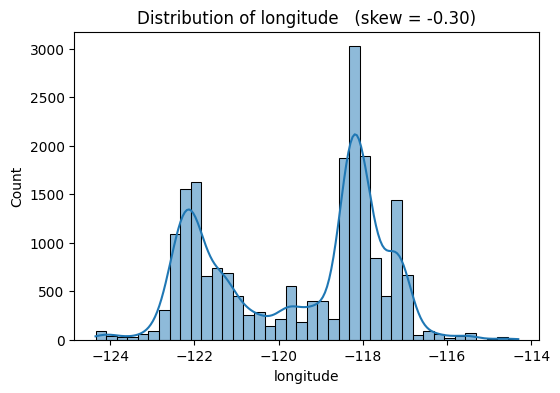

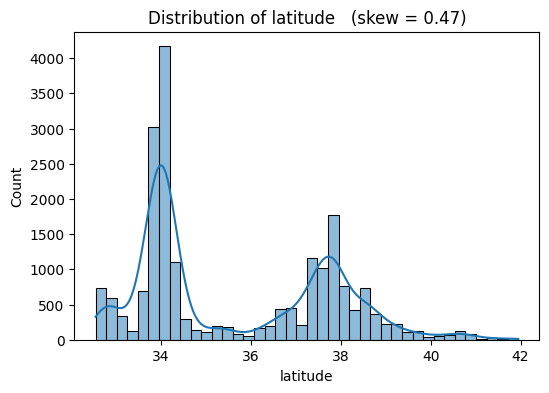

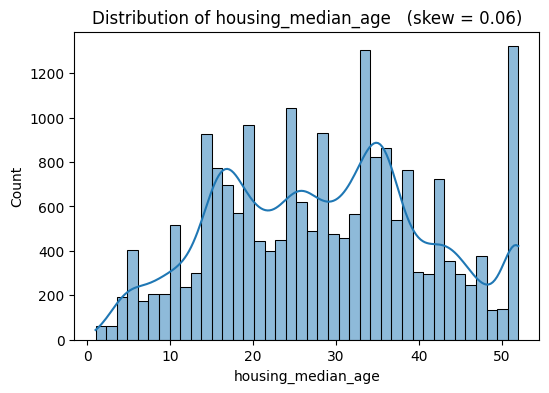

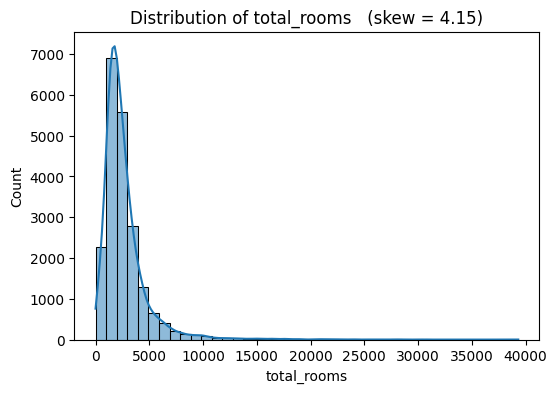

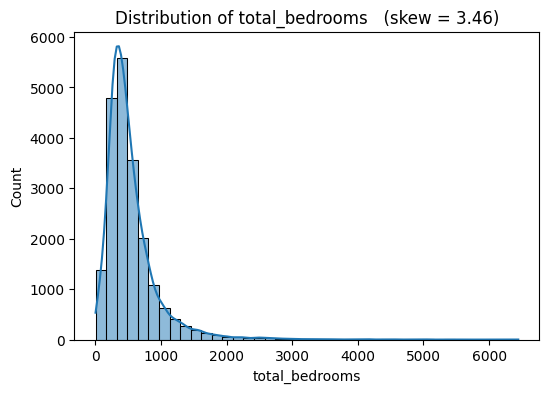

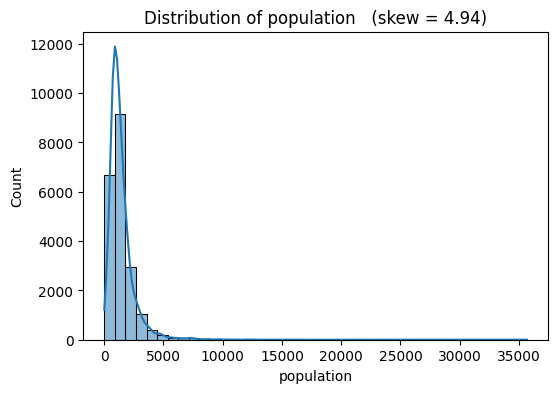

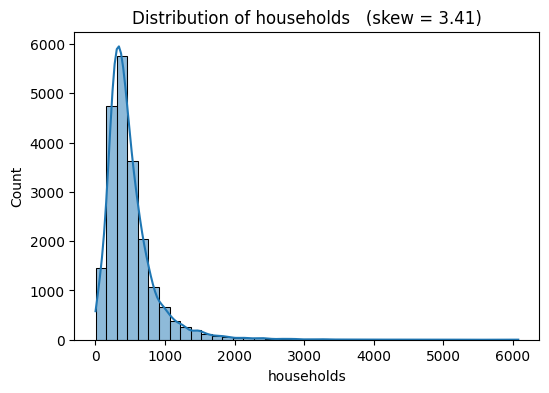

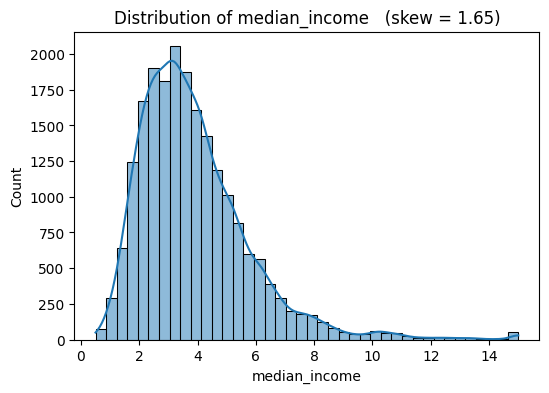

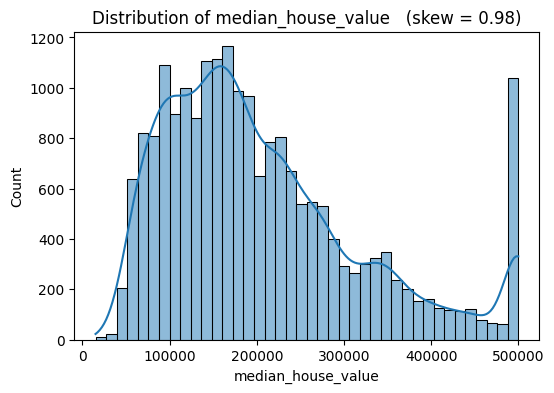

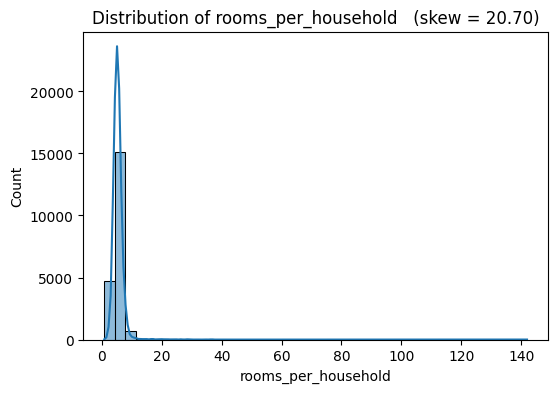

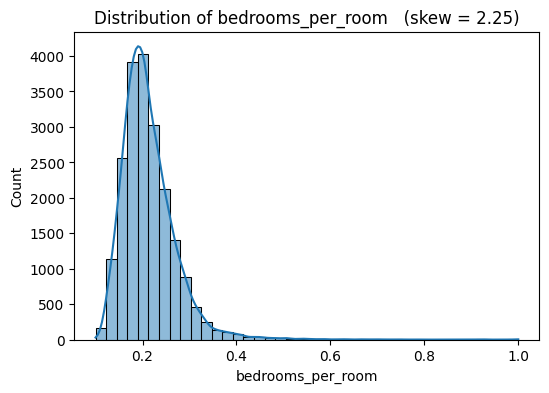

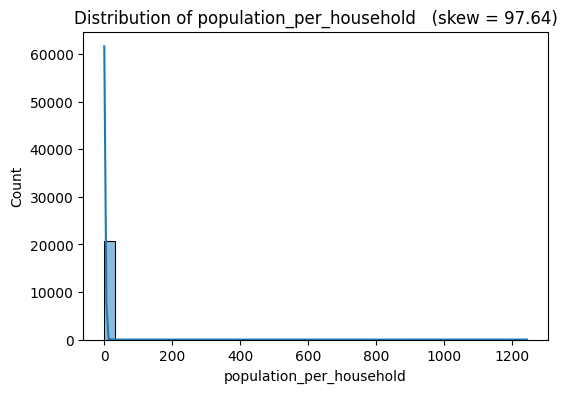

In [34]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f"Distribution of {col}   (skew = {df[col].skew():.2f})")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [35]:
# === Create derived features, transform skewed features, and re-check correlations ===
import numpy as np

# 1) Derived features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# 2) Columns we saw with skew > 1
skew_cols = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

# 3) Apply log1p transform (works fine even if zeros present)
for c in skew_cols:
    df[c + '_log1p'] = np.log1p(df[c])

# 4) Quick check: new skew values
skew_report = df[[c + '_log1p' for c in skew_cols] + 
                 ['rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'median_house_value']].skew()
print("Skew after log1p (lower is better):\n", skew_report)

# 5) Correlation of derived features with target
corr_cols = ['rooms_per_household', 'population_per_household', 'bedrooms_per_room',
             'total_rooms_log1p', 'total_bedrooms_log1p', 'population_log1p', 'households_log1p', 'median_income_log1p',
             'median_house_value']
print("\nCorrelation matrix (derived + transformed):\n")
display(df[corr_cols].corr()['median_house_value'].sort_values(ascending=False))

Skew after log1p (lower is better):
 total_rooms_log1p           -1.075533
total_bedrooms_log1p        -0.992813
population_log1p            -1.044087
households_log1p            -1.051607
median_income_log1p          0.226083
rooms_per_household         20.697869
bedrooms_per_room            2.251868
population_per_household    97.639561
median_house_value           0.977763
dtype: float64

Correlation matrix (derived + transformed):



median_house_value          1.000000
median_income_log1p         0.669914
total_rooms_log1p           0.159422
rooms_per_household         0.151948
households_log1p            0.073612
total_bedrooms_log1p        0.053311
population_log1p           -0.021205
population_per_household   -0.023737
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

In [36]:
df_clean = df.copy()

df_clean['rooms_per_household'] = df_clean['total_rooms'] / df_clean['households']
df_clean['bedrooms_per_room'] = df_clean['total_bedrooms'] / df_clean['total_rooms']
df_clean['rooms_per_household'] = df_clean['rooms_per_household'].clip(0, 20)
df_clean['bedrooms_per_room'] = df_clean['bedrooms_per_room'].clip(0, 1)

log_features = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

for col in log_features:
    df_clean[col + "_log1p"] = np.log1p(df_clean[col])

df_clean = df_clean.drop(columns=[
    'population_per_household',
])

df_clean = df_clean.drop(columns=[
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income'
])

print("Final columns in cleaned dataset:\n")
print(df_clean.columns)

print("\nShape of cleaned dataset:", df_clean.shape)

df_clean.head()


Final columns in cleaned dataset:

Index(['longitude', 'latitude', 'housing_median_age', 'median_house_value',
       'ocean_proximity', 'rooms_per_household', 'bedrooms_per_room',
       'total_rooms_log1p', 'total_bedrooms_log1p', 'population_log1p',
       'households_log1p', 'median_income_log1p'],
      dtype='object')

Shape of cleaned dataset: (20640, 12)


,longitude,latitude,housing_median_age,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,total_rooms_log1p,total_bedrooms_log1p,population_log1p,households_log1p,median_income_log1p
0,-122.23,37.88,41.0,452600.0,NEAR BAY,6.984127,0.146591,6.781058,4.867534,5.777652,4.844187,2.232720
1,-122.22,37.86,21.0,358500.0,NEAR BAY,6.238137,0.155797,8.867850,7.009409,7.784057,7.037906,2.230165
2,-122.24,37.85,52.0,352100.0,NEAR BAY,8.288136,0.129516,7.291656,5.252273,6.208590,5.181784,2.111110
3,-122.25,37.85,52.0,341300.0,NEAR BAY,5.817352,0.184458,7.150701,5.463832,6.326149,5.393628,1.893579
4,-122.25,37.85,52.0,342200.0,NEAR BAY,6.281853,0.172096,7.395108,5.638355,6.338594,5.560682,1.578195
